In [11]:
!pip -q install h5py

import os
import random
import numpy as np
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from google.colab import files

# -----------------------------
# Reproducibility
# -----------------------------
def set_seed(seed=1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True  # faster in Colab

set_seed(1337)

# -----------------------------
# Upload H5 file
# -----------------------------
uploaded = files.upload()  # square-lattice-tm-res64-filtered.h5
h5_path = next(iter(uploaded.keys()))
print("Uploaded:", h5_path)

Saving square-lattice-tm-res64-filtered.h5 to square-lattice-tm-res64-filtered (1).h5
Uploaded: square-lattice-tm-res64-filtered (1).h5


**robust key detection + helpers**

In [12]:

def normalize_epsilon(eps: np.ndarray, mode="minmax"):
    eps = eps.astype(np.float32)

    if mode == "none":
        return eps

    if mode == "minmax":
        mn, mx = float(eps.min()), float(eps.max())
        return np.zeros_like(eps) if (mx - mn) < 1e-8 else (eps - mn) / (mx - mn)

    if mode == "zscore":
        mu, sig = float(eps.mean()), float(eps.std())
        return np.zeros_like(eps) if sig < 1e-8 else (eps - mu) / sig

    raise ValueError(f"Unknown normalization mode: {mode}")


def detect_root_and_ids(f: h5py.File):
    if "shapes" in f:
        root = f["shapes"]
        ids = list(root.keys())
        return root, ids

    ids = [k for k in f.keys() if isinstance(f[k], h5py.Group)]
    if not ids:
        raise KeyError("Could not find samples: expected 'shapes' group or top-level sample groups.")
    return f, ids


def edges_from_eigfreqs(freqs: np.ndarray, gap_band: int = 1):
    # gap_band=1 means between bands 1&2 (indices 0 and 1)
    b = gap_band - 1

    if freqs.ndim != 2 or freqs.shape[1] <= b + 1:
        raise ValueError(f"eigfreqs must be (K,B) with B >= {b+2}; got {freqs.shape}")

    lo = float(np.nanmax(freqs[:, b]))
    hi = float(np.nanmin(freqs[:, b + 1]))
    return lo, hi


def gap_ratio_from_edges(omega_low: float, omega_high: float):
    gap = max(0.0, omega_high - omega_low)
    mid = 0.5 * (omega_low + omega_high)
    return 0.0 if (not np.isfinite(mid) or mid <= 0) else float(gap / mid)


def scalar_last(x):
    arr = np.asarray(x).reshape(-1)
    if arr.size == 0:
        raise ValueError("Cannot extract scalar from empty array.")
    return float(arr[-1])


def get_gap_ratio_from_group(g: h5py.Group, gap_band: int = 1):
    """
    Prefer stored bandgap label if present; else compute from eigfreqs.
    Returns: (omega_low, omega_high, gap_ratio, ok_bool)
    """
    # 1) If bandgap_1 exists, use it for ratio
    # Many datasets store [gap_size, gap_ratio] in bandgap_1.
    if "bandgap_1" in g:
        bg = g["bandgap_1"][:]

        # robust scalar extraction
        if np.ndim(bg) == 0:
            gr = float(np.asarray(bg).item())
        else:
            gr = scalar_last(bg)

        # compute edges from eigfreqs for regression targets
        freqs = g["eigfreqs"][:].astype(np.float32)
        if not np.isfinite(freqs).all():
            return None, None, None, False

        omega_low, omega_high = edges_from_eigfreqs(freqs, gap_band=gap_band)

        if not (np.isfinite(omega_low) and np.isfinite(omega_high) and np.isfinite(gr)):
            return None, None, None, False

        return omega_low, omega_high, gr, True

    # 2) Otherwise compute from eigfreqs
    freqs = g["eigfreqs"][:].astype(np.float32)
    if not np.isfinite(freqs).all():
        return None, None, None, False

    omega_low, omega_high = edges_from_eigfreqs(freqs, gap_band=gap_band)
    gr = gap_ratio_from_edges(omega_low, omega_high)

    if not (np.isfinite(omega_low) and np.isfinite(omega_high) and np.isfinite(gr)):
        return None, None, None, False

    return omega_low, omega_high, gr, True

**Built Split**

In [13]:

def stratified_split_ids(h5_path: str, thr=0.05, seed=1337, train_frac=0.8, val_frac=0.1, gap_band=1):
    with h5py.File(h5_path, "r") as f:
        root, ids = detect_root_and_ids(f)

        pos_ids, neg_ids = [], []
        skipped = 0

        for sid in ids:
            g = root[sid]
            _, _, gr, ok = get_gap_ratio_from_group(g, gap_band=gap_band)
            if not ok:
                skipped += 1
                continue
            (pos_ids if gr >= thr else neg_ids).append(str(sid))

    rng = np.random.default_rng(seed)
    rng.shuffle(pos_ids)
    rng.shuffle(neg_ids)

    def split_list(lst):
        n = len(lst)
        n_train = int(round(train_frac * n))
        n_val = int(round(val_frac * n))
        return lst[:n_train], lst[n_train:n_train+n_val], lst[n_train+n_val:]

    p_tr, p_va, p_te = split_list(pos_ids)
    n_tr, n_va, n_te = split_list(neg_ids)

    train_ids = np.array(p_tr + n_tr, dtype=object)
    val_ids   = np.array(p_va + n_va, dtype=object)
    test_ids  = np.array(p_te + n_te, dtype=object)

    rng.shuffle(train_ids)
    rng.shuffle(val_ids)
    rng.shuffle(test_ids)

    stats = {
        "total_ids": len(ids),
        "skipped_nan_or_bad": skipped,
        "positives": len(pos_ids),
        "negatives": len(neg_ids),
        "train_n": len(train_ids),
        "val_n": len(val_ids),
        "test_n": len(test_ids),
        "pos_rate": len(pos_ids) / max(1, (len(pos_ids) + len(neg_ids))),
    }
    return train_ids, val_ids, test_ids, stats


train_ids, val_ids, test_ids, stats = stratified_split_ids(
    h5_path,
    thr=0.05,
    gap_band=1,
    seed=1337
)

print(stats)

{'total_ids': 1052, 'skipped_nan_or_bad': 0, 'positives': 585, 'negatives': 467, 'train_n': 842, 'val_n': 105, 'test_n': 105, 'pos_rate': 0.5560836501901141}


**Data Set**

In [14]:
class H5GapDataset(Dataset):
    def __init__(self, h5_path, ids, eps_norm="minmax", thr=0.05, gap_band=1):
        self.h5_path = h5_path
        self.ids = ids
        self.eps_norm = eps_norm
        self.thr = thr
        self.gap_band = gap_band

        self._h5 = None
        self._root = None

    def _ensure_open(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, "r")
            self._root, _ = detect_root_and_ids(self._h5)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, i):
        self._ensure_open()

        sid = str(self.ids[i])
        g = self._root[sid]

        eps = g["unitcell"]["epsilon"][:]
        if not np.isfinite(eps).all():
            # Shouldn't happen in filtered; if it does, return a safe dummy sample
            eps = np.nan_to_num(eps, nan=0.0, posinf=0.0, neginf=0.0)

        omega_low, omega_high, gr, ok = get_gap_ratio_from_group(g, gap_band=self.gap_band)
        if not ok:
            # again, shouldn't happen in filtered. Provide safe values.
            omega_low, omega_high, gr = 0.0, 0.0, 0.0

        has_gap = 1.0 if gr >= self.thr else 0.0

        eps = normalize_epsilon(eps, self.eps_norm)

        x = torch.from_numpy(eps[None, :, :]).float()  # (1,H,W)
        y_cls = torch.tensor(has_gap, dtype=torch.float32)
        y_reg = torch.tensor([omega_low, omega_high], dtype=torch.float32)

        return x, y_cls, y_reg

    def close(self):
        if self._h5 is not None:
            try:
                self._h5.close()
            except Exception:
                pass
            self._h5 = None
            self._root = None

    def __del__(self):
        self.close()

**Model, Train and Eval**

In [18]:

class ConvBlock(nn.Module):
    def __init__(self, cin, cout, drop=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(cin, cout, 3, padding=1),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
            nn.Conv2d(cout, cout, 3, padding=1),
            nn.BatchNorm2d(cout),
            nn.ReLU(inplace=True),
        ]
        if drop > 0:
            layers.append(nn.Dropout2d(drop))
        layers.append(nn.MaxPool2d(2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class GapNet(nn.Module):
    def __init__(self, in_ch=1, base=32):
        super().__init__()
        self.enc = nn.Sequential(
            ConvBlock(in_ch, base, drop=0.00),
            ConvBlock(base, base * 2, drop=0.00),
            ConvBlock(base * 2, base * 4, drop=0.05),
            ConvBlock(base * 4, base * 4, drop=0.05),
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(base * 4, base * 4),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
        )

        self.cls = nn.Linear(base * 4, 1)
        self.reg = nn.Linear(base * 4, 2)

    def forward(self, x):
        h = self.head(self.enc(x))
        logits = self.cls(h).squeeze(-1)
        edges = self.reg(h)
        return logits, edges


@torch.no_grad()
def count_pos_in_ids(h5_path, ids, thr=0.05, gap_band=1):
    pos = 0
    total = 0
    with h5py.File(h5_path, "r") as f:
        root, _ = detect_root_and_ids(f)
        for sid in ids:
            g = root[str(sid)]
            _, _, gr, ok = get_gap_ratio_from_group(g, gap_band=gap_band)
            if not ok:
                continue
            total += 1
            if gr >= thr:
                pos += 1
    return pos, total


def f1_from_probs(y_true_np, p_np, thr):
    y_pred = (p_np >= thr).astype(np.int64)

    tp = int(((y_pred == 1) & (y_true_np == 1)).sum())
    fp = int(((y_pred == 1) & (y_true_np == 0)).sum())
    fn = int(((y_pred == 0) & (y_true_np == 1)).sum())

    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = 2 * prec * rec / max(1e-12, (prec + rec))
    acc = float((y_pred == y_true_np).mean())
    return f1, acc


@torch.no_grad()
def evaluate(model, loader, device, bce_loss):
    model.eval()

    total = 0
    loss_cls_sum = 0.0

    probs_all = []
    ytrue_all = []

    reg_n = 0
    mae_low = 0.0
    mae_high = 0.0

    for x, y_cls, y_reg in loader:
        x, y_cls, y_reg = x.to(device), y_cls.to(device), y_reg.to(device)

        logits, edges = model(x)

        loss_cls_sum += float(bce_loss(logits, y_cls).detach()) * x.size(0)
        total += x.size(0)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ytrue = (y_cls.detach().cpu().numpy() > 0.5).astype(np.int64)
        probs_all.append(probs)
        ytrue_all.append(ytrue)

        pos = (y_cls > 0.5)
        if int(pos.sum()) > 0:
            e = edges[pos]
            y = y_reg[pos]
            mae_low += float(torch.abs(e[:, 0] - y[:, 0]).sum())
            mae_high += float(torch.abs(e[:, 1] - y[:, 1]).sum())
            reg_n += int(pos.sum())

    p_np = np.concatenate(probs_all, axis=0)
    y_np = np.concatenate(ytrue_all, axis=0)

    thresholds = np.linspace(0.05, 0.95, 19)
    best_f1, best_thr, best_acc = -1.0, 0.5, 0.0
    for t in thresholds:
        f1, acc = f1_from_probs(y_np, p_np, t)
        if f1 > best_f1:
            best_f1, best_thr, best_acc = f1, t, acc

    mae_low = (mae_low / reg_n) if reg_n else None
    mae_high = (mae_high / reg_n) if reg_n else None

    return {
        "loss_cls": loss_cls_sum / max(1, total),
        "best_f1": float(best_f1),
        "best_thr": float(best_thr),
        "best_acc": float(best_acc),
        "mae_omega_low": mae_low,
        "mae_omega_high": mae_high,
        "reg_count": int(reg_n),
        "reg_score": (mae_low + mae_high) if (mae_low is not None and mae_high is not None) else 1e9,
    }


def train_h5_earlystop(
    h5_path,
    train_ids,
    val_ids,
    test_ids,
    thr=0.05,
    gap_band=1,
    epochs=80,
    batch=128,
    lr=3e-5,
    lambda_reg=1.0,
    base=32,
    eps_norm="minmax",
    patience=10,
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    train_ds = H5GapDataset(h5_path, train_ids, eps_norm=eps_norm, thr=thr, gap_band=gap_band)
    val_ds   = H5GapDataset(h5_path, val_ids,   eps_norm=eps_norm, thr=thr, gap_band=gap_band)
    test_ds  = H5GapDataset(h5_path, test_ids,  eps_norm=eps_norm, thr=thr, gap_band=gap_band)

    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_ds,  batch_size=batch, shuffle=False, num_workers=0)

    model = GapNet(base=base).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=3
    )

    pos, total = count_pos_in_ids(h5_path, train_ids, thr=thr, gap_band=gap_band)
    neg = total - pos
    pos_weight = torch.tensor([neg / max(1, pos)], device=device, dtype=torch.float32)

    print(f"Train positives={pos}/{total} ({(pos/max(1,total))*100:.1f}%), pos_weight={pos_weight.item():.3f}")

    bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    reg_loss_fn = nn.SmoothL1Loss(reduction="none")

    best_state = None
    best_val_score = 1e9
    bad_epochs = 0
    prev_lr = opt.param_groups[0]["lr"]

    for ep in range(1, epochs + 1):
        model.train()
        running = 0.0

        for x, y_cls, y_reg in train_loader:
            x, y_cls, y_reg = x.to(device), y_cls.to(device), y_reg.to(device)

            logits, edges = model(x)

            loss_cls = bce(logits, y_cls)

            mask = (y_cls > 0.5).float().unsqueeze(1)
            diff = reg_loss_fn(edges, y_reg)
            loss_reg = (diff * mask).sum() / (mask.sum() * 2.0 + 1e-8)

            loss = loss_cls + lambda_reg * loss_reg

            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            running += float(loss.detach()) * x.size(0)

        train_loss = running / max(1, len(train_ds))
        val = evaluate(model, val_loader, device, bce_loss=bce)
        scheduler.step(val["reg_score"])

        current_lr = opt.param_groups[0]["lr"]
        lr_msg = f" | lr={current_lr:.2e}"
        if current_lr != prev_lr:
            lr_msg += " (reduced)"
        prev_lr = current_lr

        print(
            f"Epoch {ep:03d} | train_loss={train_loss:.4f} | "
            f"val_reg_score={val['reg_score']:.4f} "
            f"(low={val['mae_omega_low']}, high={val['mae_omega_high']}) | "
            f"val_best_f1={val['best_f1']:.3f} "
            f"thr={val['best_thr']:.2f} acc@thr={val['best_acc']:.3f}"
            f"{lr_msg}"
        )

        if val["reg_score"] < best_val_score - 1e-4:
            best_val_score = val["reg_score"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {ep} (no reg improvement for {patience} epochs).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    test = evaluate(model, test_loader, device, bce_loss=bce)
    print("\nTEST:", test)

    return model, test

**Run Training**

In [19]:
# -----------------------------
# Run
# -----------------------------
model, test_metrics = train_h5_earlystop(
    h5_path,
    train_ids,
    val_ids,
    test_ids,
    thr=0.05,
    gap_band=1,
    epochs=80,
    batch=128,
    lr=3e-5,
    lambda_reg=1.0,
    base=32,
    eps_norm="minmax",
    patience=10,
)

Device: cuda
Train positives=468/842 (55.6%), pos_weight=0.799
Epoch 001 | train_loss=0.7205 | val_reg_score=1.1700 (low=0.8380887261752424, high=0.331961204265726) | val_best_f1=0.712 thr=0.05 acc@thr=0.552 | lr=3.00e-05
Epoch 002 | train_loss=0.6893 | val_reg_score=1.1105 (low=0.8201687253754715, high=0.29030040214801656) | val_best_f1=0.712 thr=0.05 acc@thr=0.552 | lr=3.00e-05
Epoch 003 | train_loss=0.6636 | val_reg_score=1.0490 (low=0.7947162759715113, high=0.25423395222630996) | val_best_f1=0.712 thr=0.05 acc@thr=0.552 | lr=3.00e-05
Epoch 004 | train_loss=0.6514 | val_reg_score=0.9513 (low=0.7424294701937971, high=0.20888228252016264) | val_best_f1=0.712 thr=0.05 acc@thr=0.552 | lr=3.00e-05
Epoch 005 | train_loss=0.6391 | val_reg_score=0.8202 (low=0.6470781523605873, high=0.17312756900129647) | val_best_f1=0.712 thr=0.05 acc@thr=0.552 | lr=3.00e-05
Epoch 006 | train_loss=0.6304 | val_reg_score=0.6597 (low=0.5223352169168407, high=0.13737898859484443) | val_best_f1=0.716 thr=0.50 a

**Final Eval + Plots**


=== FINAL OUTPUT (threshold chosen on VAL) ===
Chosen threshold: 0.39999999999999997

VAL classification @ thr: {'acc': 0.638095238095238, 'precision': 0.6111111111111112, 'recall': 0.9482758620689655, 'specificity': 0.2553191489361702, 'balanced_acc': 0.6017975055025678, 'f1': 0.7432432432432432, 'tp': 55, 'fp': 35, 'tn': 12, 'fn': 3}

TEST classification @ val_thr: {'acc': 0.6095238095238096, 'precision': 0.5918367346938775, 'recall': 0.9830508474576272, 'specificity': 0.13043478260869565, 'balanced_acc': 0.5567428150331614, 'f1': 0.7388535031847134, 'tp': 58, 'fp': 40, 'tn': 6, 'fn': 1}

TEST regression MAE on TRUE positives (n=59): omega_low=0.060311, omega_high=0.023366

(For reference) test_metrics printed during training: {'loss_cls': 0.5873987674713135, 'best_f1': 0.7388535031847134, 'best_thr': 0.39999999999999997, 'best_acc': 0.6095238095238096, 'mae_omega_low': 0.06031059006513175, 'mae_omega_high': 0.0233664553044206, 'reg_count': 59, 'reg_score': 0.08367704536955235}

Con

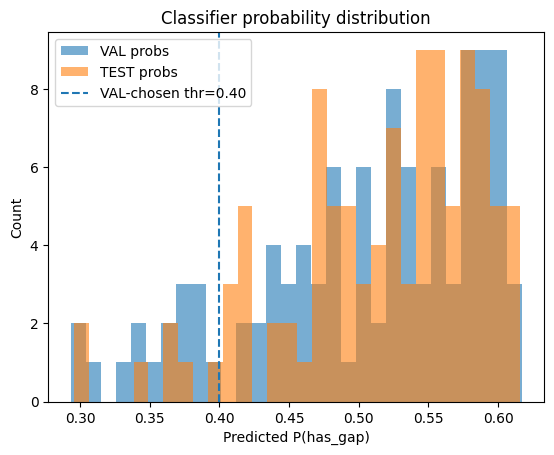

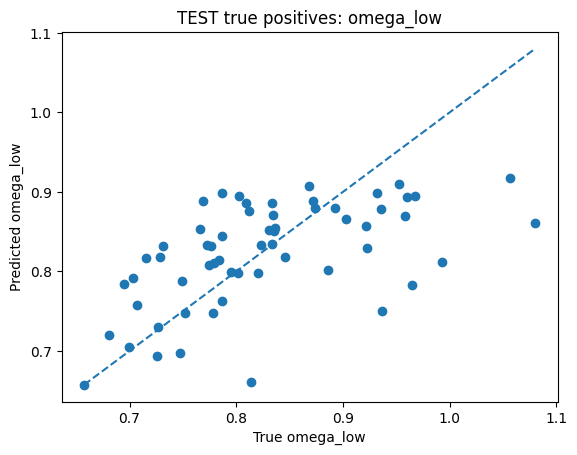

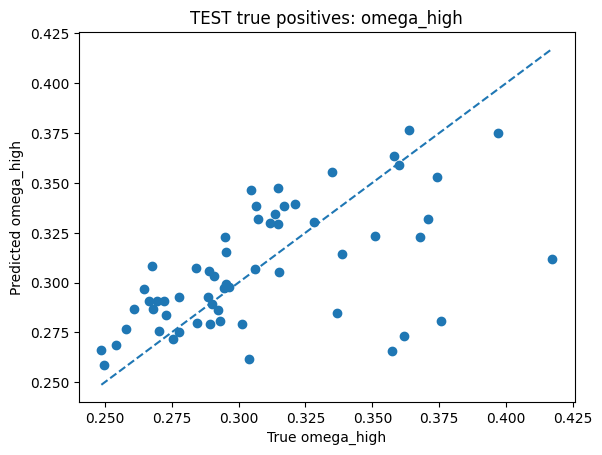

In [20]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# --- helper metrics ---
def f1_stats(y_true, y_pred):
    tp = int(((y_pred == 1) & (y_true == 1)).sum())
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    tn = int(((y_pred == 0) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())

    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = 2 * prec * rec / max(1e-12, (prec + rec))
    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    spec = tn / max(1, tn + fp)
    bal_acc = 0.5 * (rec + spec)

    return {
        "acc": acc,
        "precision": prec,
        "recall": rec,
        "specificity": spec,
        "balanced_acc": bal_acc,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }


@torch.no_grad()
def collect_all(model, loader, device):
    probs_all, ycls_all = [], []
    yreg_all, pred_edges_all = [], []

    for x, y_cls, y_reg in loader:
        x = x.to(device)
        logits, edges = model(x)

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        probs_all.append(probs)
        ycls_all.append((y_cls.numpy() > 0.5).astype(np.int64))
        yreg_all.append(y_reg.numpy())
        pred_edges_all.append(edges.detach().cpu().numpy())

    return (
        np.concatenate(probs_all, axis=0),
        np.concatenate(ycls_all, axis=0),
        np.concatenate(yreg_all, axis=0),
        np.concatenate(pred_edges_all, axis=0),
    )


def best_thr_on_val(p, y, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 19)

    best = (-1.0, 0.5, None)
    for t in grid:
        pred = (p >= t).astype(np.int64)
        st = f1_stats(y, pred)
        if st["f1"] > best[0]:
            best = (st["f1"], t, st)

    return float(best[1]), best[2]


def mae_on_true_pos(y_true_edges, y_pred_edges, y_true_cls):
    m = (y_true_cls == 1)
    if m.sum() == 0:
        return None, None, 0

    err = np.abs(y_pred_edges[m] - y_true_edges[m])
    return float(err[:, 0].mean()), float(err[:, 1].mean()), int(m.sum())


# --- build loaders ---
val_ds = H5GapDataset(h5_path, val_ids, eps_norm="minmax", thr=0.05, gap_band=1)
test_ds = H5GapDataset(h5_path, test_ids, eps_norm="minmax", thr=0.05, gap_band=1)

val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=0)

# --- collect ---
p_val, y_val, yreg_val, pred_edges_val = collect_all(model, val_loader, device)
p_test, y_test, yreg_test, pred_edges_test = collect_all(model, test_loader, device)

# --- choose threshold on VAL ---
thr_val, val_stats = best_thr_on_val(p_val, y_val)
yhat_test = (p_test >= thr_val).astype(np.int64)
test_stats = f1_stats(y_test, yhat_test)

# --- regression MAE on TEST true positives ---
mae_low, mae_high, npos = mae_on_true_pos(yreg_test, pred_edges_test, y_test)

print("\n=== FINAL OUTPUT (threshold chosen on VAL) ===")
print("Chosen threshold:", thr_val)
print("\nVAL classification @ thr:", val_stats)
print("\nTEST classification @ val_thr:", test_stats)
print(f"\nTEST regression MAE on TRUE positives (n={npos}): omega_low={mae_low:.6f}, omega_high={mae_high:.6f}")
print("\n(For reference) test_metrics printed during training:", test_metrics)

# --- confusion matrix (printed) ---
cm = np.array([
    [test_stats["tn"], test_stats["fp"]],
    [test_stats["fn"], test_stats["tp"]],
], dtype=int)

print("\nConfusion matrix on TEST (rows=true 0/1, cols=pred 0/1):\n", cm)

# --- Plot 1: probability histograms ---
plt.figure()
plt.hist(p_val, bins=30, alpha=0.6, label="VAL probs")
plt.hist(p_test, bins=30, alpha=0.6, label="TEST probs")
plt.axvline(thr_val, linestyle="--", label=f"VAL-chosen thr={thr_val:.2f}")
plt.xlabel("Predicted P(has_gap)")
plt.ylabel("Count")
plt.title("Classifier probability distribution")
plt.legend()
plt.show()

# --- Plot 2: true vs predicted edges on TEST true positives ---
mask = (y_test == 1)

plt.figure()
plt.scatter(yreg_test[mask, 0], pred_edges_test[mask, 0])
lims = [
    min(yreg_test[mask, 0].min(), pred_edges_test[mask, 0].min()),
    max(yreg_test[mask, 0].max(), pred_edges_test[mask, 0].max()),
]
plt.plot(lims, lims, "--")
plt.xlabel("True omega_low")
plt.ylabel("Predicted omega_low")
plt.title("TEST true positives: omega_low")
plt.show()

plt.figure()
plt.scatter(yreg_test[mask, 1], pred_edges_test[mask, 1])
lims = [
    min(yreg_test[mask, 1].min(), pred_edges_test[mask, 1].min()),
    max(yreg_test[mask, 1].max(), pred_edges_test[mask, 1].max()),
]
plt.plot(lims, lims, "--")
plt.xlabel("True omega_high")
plt.ylabel("Predicted omega_high")
plt.title("TEST true positives: omega_high")
plt.show()